# EDA(cleaned_gurgaon_v2.csv)
    1) Univariate Analysis
    2) Multivariate Analysis

    here in this notebook i will perform 'Univariate Anlaysis'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:\\capstone_project_dscience\\real_estate_project\\dataset\\cleaned_gurgaon_v2.csv')

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
df.shape

(3807, 30)

In [4]:
df = df.sample(df.shape[0])

In [5]:
df.duplicated().sum()

np.int64(131)

    there are 131 duplicate values, so let's first remove it

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 3676 entries, 2617 to 3610
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3676 non-null   str    
 1   sector               3676 non-null   str    
 2   society              3238 non-null   str    
 3   price                3675 non-null   float64
 4   price_per_sqft       3675 non-null   float64
 5   area                 3675 non-null   float64
 6   super_built_up_area  1888 non-null   float64
 7   built_up_area        2870 non-null   float64
 8   carpet_area          1888 non-null   float64
 9   bedRoom              3676 non-null   float64
 10  bathroom             3676 non-null   float64
 11  balcony              3676 non-null   str    
 12  floorNum             3658 non-null   float64
 13  agePossession        3675 non-null   str    
 14  store room           3676 non-null   int64  
 15  servant room         3676 non-null   int64  
 16  p

 **property_type**

In [8]:
df['property_type'].value_counts()

property_type
flat     2889
house     787
Name: count, dtype: int64

<Axes: xlabel='property_type', ylabel='count'>

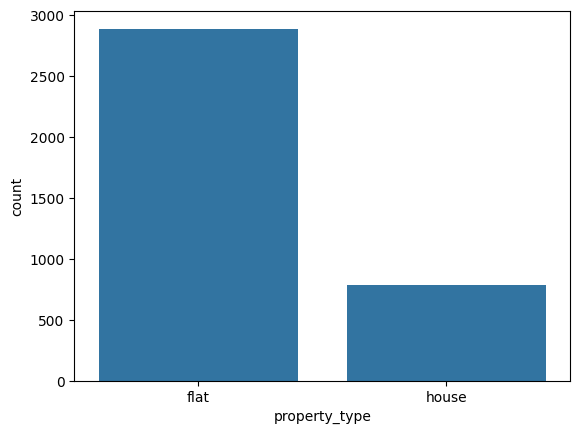

In [9]:
sns.barplot(df['property_type'].value_counts())

**sector**

In [10]:
df['sector'].value_counts()

sector
sohna                      158
sector 37                  119
sector 85                  111
sector 102                 107
sector 70                  104
sector 92                   99
sector 69                   94
sector 90                   88
sector 81                   87
sector 65                   87
sector 109                  81
sector 1                    80
sector 79                   76
sector 33                   74
sector 104                  74
sector 67                   70
sector 83                   68
sector 89                   66
sector 86                   65
sector 95                   62
sector 50                   62
sector 82                   60
sector 107                  60
sector 108                  59
sector 43                   58
sector 56                   55
sector 48                   55
sector 84                   49
sector 49                   49
sector 26                   48
sector 113                  46
sector 61                   46
s

In [11]:
df[df['sector'] == 'new']

,property_type,sector,society,price,price_per_sqft,area,super_built_up_area,built_up_area,carpet_area,bedRoom,bathroom,balcony,floorNum,agePossession,store room,servant room,pooja room,study room,others,East,North,North-East,North-West,South,South-East,South-West,Unknown,West,furnish_type,luxury_score
2887,flat,new,dlf,4.00,11428.0,3500.18,NaN,NaN,3500.0,4.0,4.0,2,4.0,under construction,0,1,0,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2,313.0
3771,flat,new,sare homes,0.85,4786.0,1776.01,1776.0,1776.0,NaN,4.0,4.0,3,3.0,moderately old,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,NaN
3708,flat,new,green court,0.38,5507.0,690.03,NaN,NaN,690.0,2.0,2.0,1,7.0,unknown,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,97.0
3619,flat,new,takshila heights sector c,0.67,5583.0,1200.07,1200.0,1200.0,NaN,2.0,2.0,2,3.0,relatively new,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,104.0


    replace sector of index:
    2887 -> sector 42
    3771 -> sector 49
    3619 -> sector 37
    3708 -> sector 90

In [12]:
df.loc[2887,'sector'] = 'sector 42'
df.loc[3771,'sector'] = 'sector 49'
df.loc[3619,'sector'] = 'sector 37'
df.loc[3708,'sector'] = 'sector 90'

    here as there are so many sectors, i will plot only the top 10, to avoid congestion.

<Axes: xlabel='sector'>

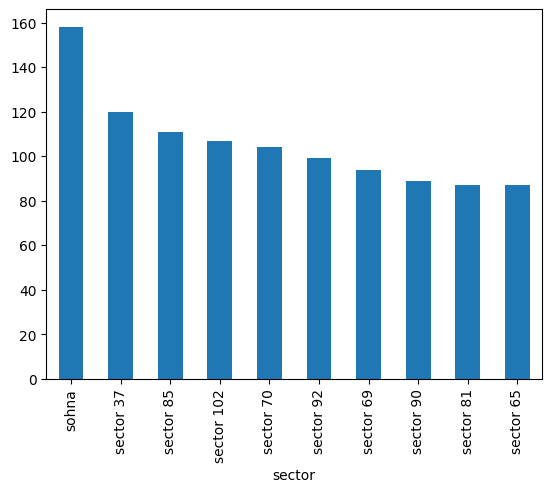

In [13]:
df['sector'].value_counts()[:10].plot(kind='bar')

    now lets make frequency bins. so for this i have to make bins.
        1) 'very high(>100)' : if sector_count > 100
        2) 'high' : if 60<sector_count<100
        3) 'moderate' : if 20<sector_count<60
        4) 'low' : if 5<sector_count<20
        5) 'very low' : if sector_count <5

In [14]:
sector_count = df['sector'].value_counts()

In [15]:
frequency_bins = {
    'very high(>100)' : (sector_count > 100).sum(),
    'high(50-100)' : ((sector_count > 50) & (sector_count <= 100)).sum(),
    'medium(10-50)' : ((sector_count > 10) & (sector_count <= 50)).sum(),
    'low(1-10)' : ((sector_count > 1) & (sector_count <= 10)).sum(),
    'very low(<=1)' : (sector_count <= 1).sum()
}

frequency_bins

{'very high(>100)': np.int64(5),
 'high(50-100)': np.int64(22),
 'medium(10-50)': np.int64(50),
 'low(1-10)': np.int64(25),
 'very low(<=1)': np.int64(1)}

In [16]:
df['sector'].isnull().sum()

np.int64(0)

In [17]:
df['sector'].unique().shape

(103,)

    Observations:
    1) there are a total of 103 unique sectors in the dataset
    2)  frequency distribution:
        'very high(>100)': 5 sectors have more than 100 frequency,
        'high(50-100)': 22 sectors have more than 50 and less than 100 frequency,
        'medium(10-50)': 50 sectors have more than 10 and less than 50 frequency,
        'low(1-10)': 26 sectors have more than 1 and less than 10 frequency,
        'very low(<=1)': 0 sectors have more than or equal to 1 frequency
    

**society**

In [18]:
df['society'].value_counts()

society
tulip violet.                                     73
ss the leaf.                                      72
shapoorji pallonji joyville gurugram.             38
dlf new town heights .                            38
smart world gems                                  37
smart world orchard                               37
signature global park.                            35
shree vardhman victoria.                          34
paras dews                                        32
emaar mgf emerald floors premier.                 32
godrej nature plus                                32
dlf the ultima.                                   31
dlf regal gardens.                                30
la vida by tata housing                           30
international city by sobha phase                 29
shree vardhman flora.                             29
mm woodshire.                                     29
signature global solera.                          27
bptp terra.                           

<Axes: xlabel='society'>

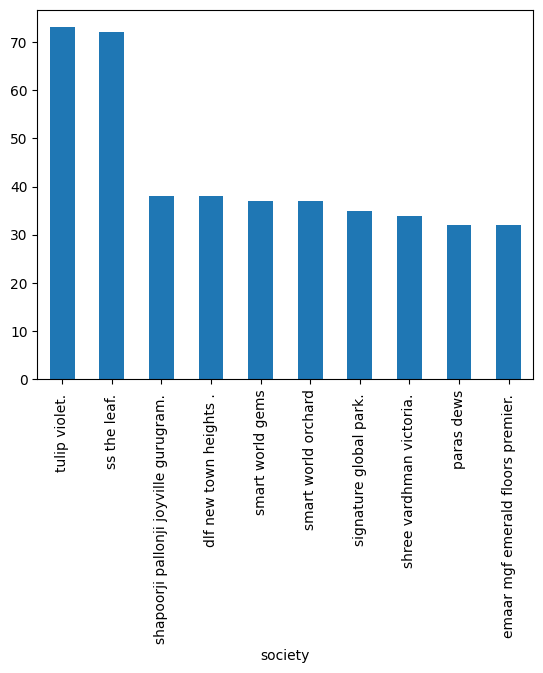

In [19]:
df['society'].value_counts().head(10).plot(kind='bar')

In [35]:
((df['society'].value_counts().cumsum()/df['society'].value_counts().sum())*100).head(75)

society
tulip violet.                              2.267785
ss the leaf.                               4.504505
shapoorji pallonji joyville gurugram.      5.684995
dlf new town heights .                     6.865486
smart world gems                           8.014911
smart world orchard                        9.164337
signature global park.                    10.251631
shree vardhman victoria.                  11.307860
paras dews                                12.301957
emaar mgf emerald floors premier.         13.296055
godrej nature plus                        14.290152
dlf the ultima.                           15.253184
dlf regal gardens.                        16.185151
la vida by tata housing                   17.117117
international city by sobha phase         18.018018
shree vardhman flora.                     18.918919
mm woodshire.                             19.819820
signature global solera.                  20.658590
bptp terra.                               21.435228
tata

    1)from here as we can see that 50 percent of the value counts are covered by top 75 socities
    2)most frequent socities are 'tulip violet' and 'ss the leaf'

**price**

In [36]:
df['price'].value_counts()

price
1.2500     82
1.2000     67
1.5000     64
1.1000     63
1.4000     62
0.9000     61
1.3000     60
2.0000     54
0.9500     51
1.7500     49
1.6000     49
1.3500     47
1.0000     47
0.7500     44
1.7000     44
0.8000     42
1.6500     42
0.5000     42
1.8000     41
1.9000     41
1.5500     41
0.8500     37
1.1500     36
2.5000     36
2.2000     33
1.4500     33
0.4500     31
0.4000     31
2.1000     31
0.7000     30
0.6000     30
3.5000     30
1.0500     28
0.6500     27
2.2500     25
2.3500     24
1.8500     24
3.0000     23
6.5000     22
0.3500     22
0.5500     21
2.3000     20
5.5000     20
2.4000     20
5.0000     20
4.0000     19
3.2500     18
3.4000     17
6.0000     17
2.6000     17
2.6500     16
0.8200     15
0.3800     15
2.4500     15
2.8000     15
0.9200     15
0.3000     15
2.1500     15
1.9500     15
1.3800     15
0.3200     14
8.5000     14
2.7000     14
0.4200     14
4.2500     14
4.5000     14
1.3200     13
0.7800     13
7.0000     13
1.0800     12
1.4200     12


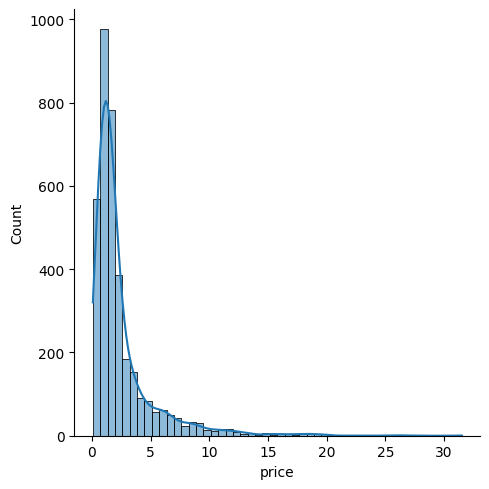

In [37]:
sns.displot(df['price'], bins=50, kde=True)

In [38]:
df['price'].skew()

np.float64(3.418687020661723)

the skew value is approximately 3.37, indicating a positive skew. this means that our distribution tail is skewed to the right and we can also verify the same by looking at the histogram where there are less properties with higher price and more properties with less price 

In [39]:
df['price'].kurtosis()

np.float64(16.376973103066703)

the kurtosis value is approximately 15.91, kurtosis value greater than 3 indicates a distribution with heavier tails and more outliers compared to a normal distribution

In [40]:
df['price'].describe()

count    3644.000000
mean        2.462214
std         2.891547
min         0.075000
25%         0.950000
50%         1.500000
75%         2.622500
max        31.500000
Name: price, dtype: float64

In [41]:
df['price'].isnull().sum()

np.int64(0)

<Axes: ylabel='price'>

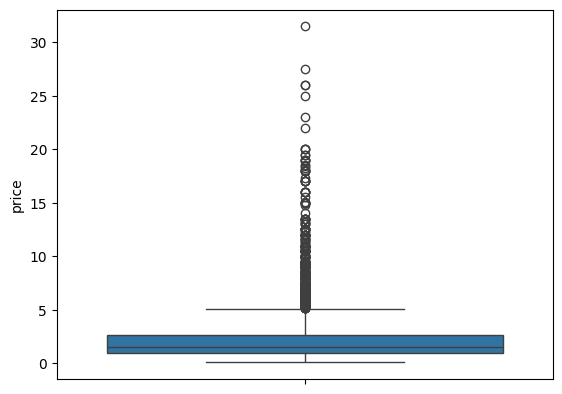

In [42]:
sns.boxplot(df['price'])

    1) mean is 2.49 crore
    2) median is 1.51 crore, differene between mean and median clearly showing that there are outliers present in the column
    3) the maximum value is 31.5 crore
    4) 50% of the houses price is less than or equal to 1.5 crore
    5) minimum value is 0.075 crore
    6) standard deviation= 2.933 crore

    BOX Plot
    1)most of the properties are lies in the price range less than 5 crore. with very few properties going above 10 crores.
    2)properties above the 10 crore price will be considered as outliers because they lie above the upper whisker.

In [43]:
df[df['price'] > 10].shape

(107, 30)

    now lets find out the potential outliers using the IQR method

In [44]:
Q1 = df['price'].describe()['25%']
Q3 = df['price'].describe()['75%']
IQR = Q3 - Q1

calculated the upper bound and lower bound of the data values

In [45]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [46]:
outliers = df[(df['price'] > upper_bound) | (df['price'] < lower_bound)]['price']

In [47]:
outliers.shape

(417,)

In [48]:
outliers.describe()

count    417.000000
mean       8.977194
std        4.080673
min        5.150000
25%        6.150000
50%        7.520000
75%       10.450000
max       31.500000
Name: price, dtype: float64

    so in the price column there are total of 429 outliers
    1) range - (5.25-31.5) crore
    2) standard deviation = 4.08 crore
    3) outliers have an average price of 9.043 crore

<Axes: xlabel='price'>

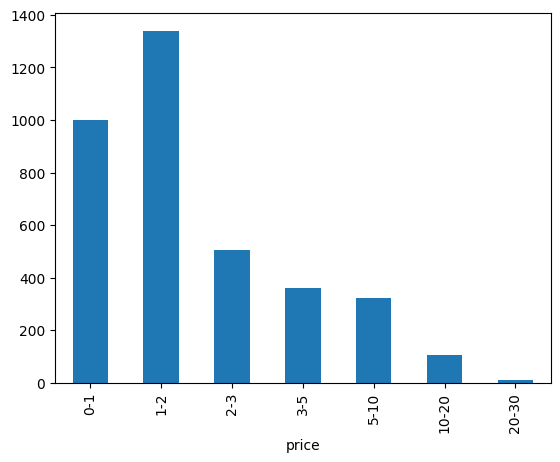

In [49]:
bins = [0,1,2,3,5,10,20,30]
labels = ['0-1','1-2','2-3','3-5','5-10','10-20','20-30']
pd.cut(df['price'],bins=bins,labels=labels,right=False).value_counts().sort_index().plot(kind='bar')

    1)the majority of the properties are priced between '0-1' and '1-2' crore
    2)there are very less properties with price range greater than 5 crore 

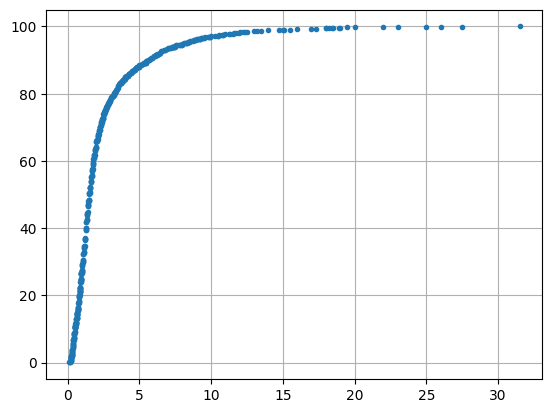

In [50]:
ecdf = (df['price'].value_counts().sort_index().cumsum()/df.shape[0])*100
plt.plot(ecdf.index, ecdf.values, marker='.', linestyle='none')
plt.grid()

    at price range 12-13 crore almost 99 percent of the properties are covered

    now lets apply the log transformation on the price column(because it is right skewed) and see whether it improves or not

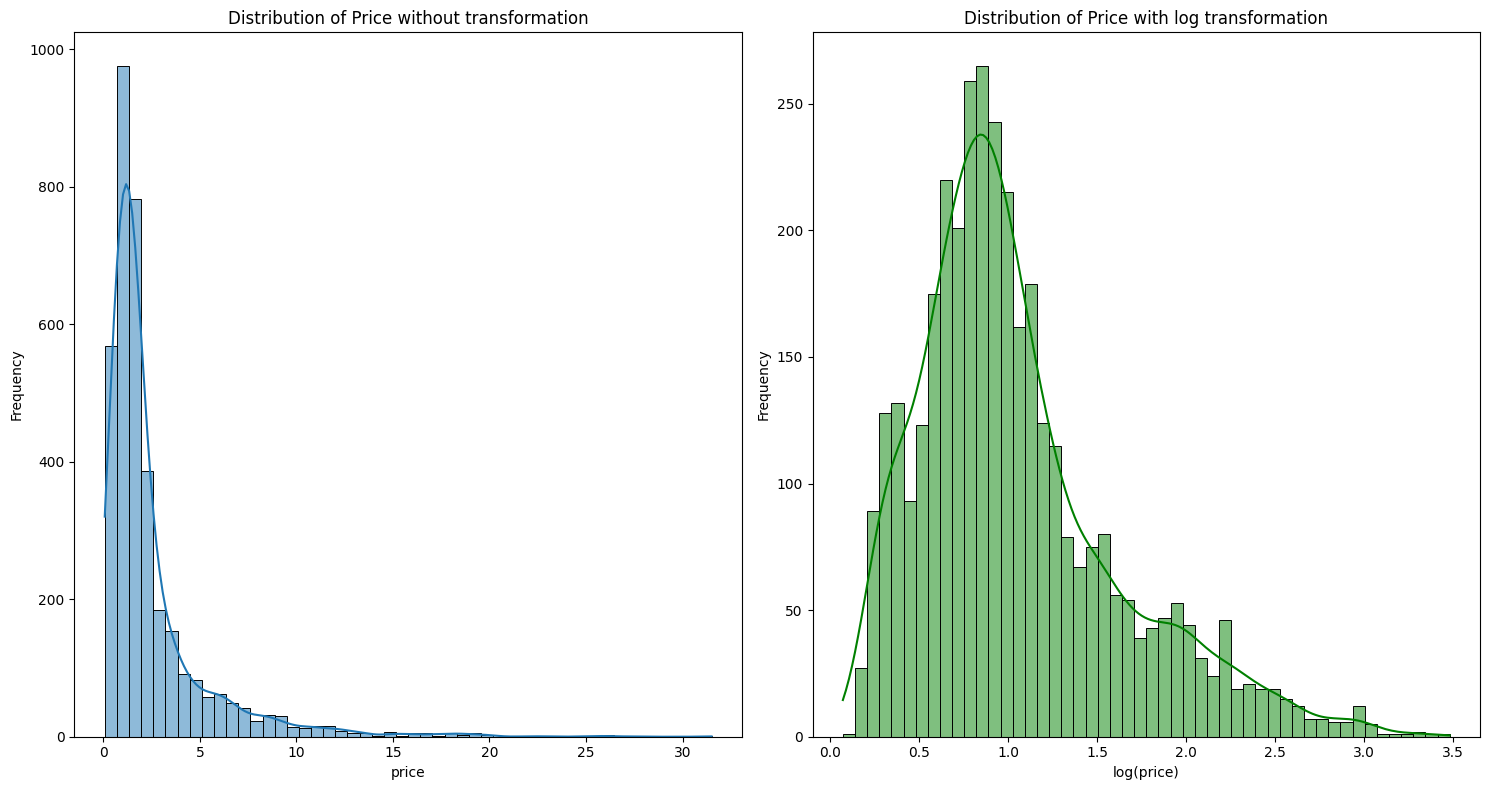

In [51]:
plt.figure(figsize=(15,8))

plt.subplot(1,2,1)
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Price without transformation')
plt.xlabel('price')
plt.ylabel('Frequency')

plt.subplot(1,2,2)
sns.histplot(np.log1p(df['price']), bins=50, kde=True, color='green')
plt.title('Distribution of Price with log transformation')
plt.xlabel('log(price)')
plt.ylabel('Frequency') 

plt.tight_layout()
plt.show()

In [52]:
skewness = np.log1p(df['price']).skew()
kurtosis = np.log1p(df['price']).kurtosis()
print(f'Skewness: {skewness}')
print(f'Kurtosis: {kurtosis}')

Skewness: 1.1024544560588228
Kurtosis: 1.1342606487008404


    as we can see that after transformation it is behaving like normal distribution
    1) kurtosis less than 3 here(means tails are not that fat)
    2) skewness is also very less(so kind of normal distribution)

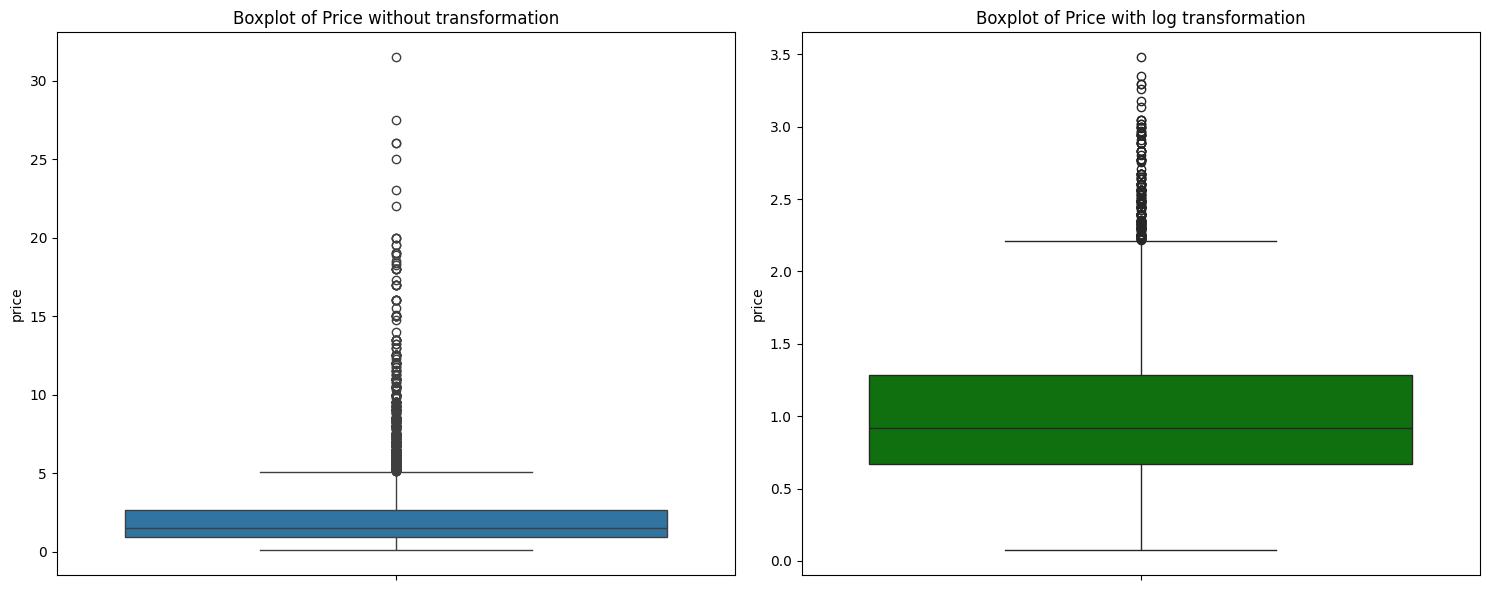

In [53]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
sns.boxplot(df['price'])
plt.title('Boxplot of Price without transformation')
plt.subplot(1,2,2)
sns.boxplot(np.log1p(df['price']), color='green')
plt.title('Boxplot of Price with log transformation')
plt.tight_layout()
plt.show()

    the outliers has also decreased after applying the log transformation

**price_per_sqft**

In [54]:
df['price_per_sqft'].isnull().sum()

np.int64(0)

In [55]:
df['price_per_sqft'].describe()

count     3644.000000
mean     11952.572173
std       9329.877713
min          4.000000
25%       6800.750000
50%       8971.000000
75%      13492.750000
max      98214.000000
Name: price_per_sqft, dtype: float64

<Axes: xlabel='price_per_sqft', ylabel='Count'>

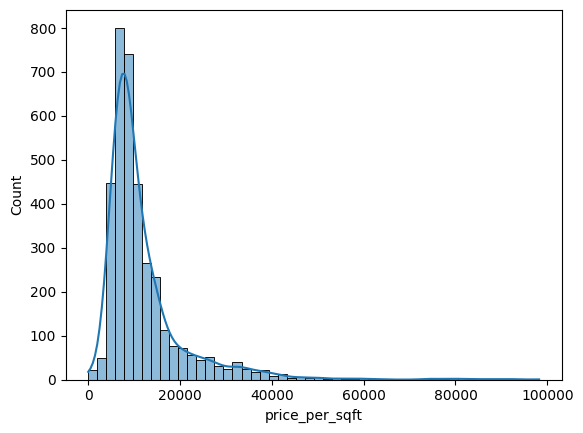

In [56]:
sns.histplot(df['price_per_sqft'], bins=50, kde=True)

In [57]:
skewness = df['price_per_sqft'].skew()
kurtosis = df['price_per_sqft'].kurtosis()
print(f'Skewness: {skewness}')
print(f'Kurtosis: {kurtosis}')

Skewness: 3.439615665879571
Kurtosis: 18.045508045747695


<Axes: ylabel='price_per_sqft'>

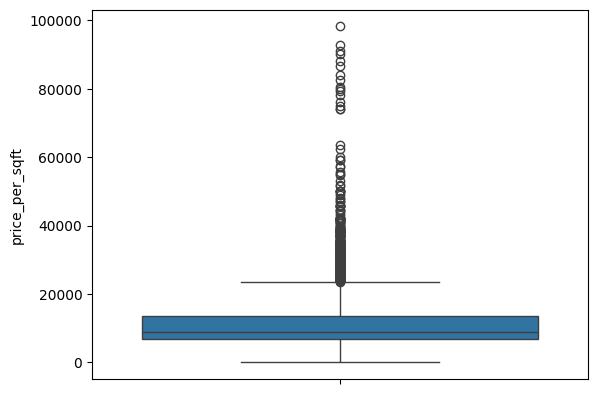

In [58]:
sns.boxplot(df['price_per_sqft'])

    1) there are outliers in the 'price_per_sqft' column(as it is also clarified by the histplot, boxplot)
    2) the kurtosis value is 186 , the value greater than 3 means that it heavier tails and more outliers as compared to the normal distribution
    3) the skew value is also highly positivie indicating that it is right skewed
    4) the mean value is 13741.05
    5) the standard deviation is 23255
    6) the median is 9000

In [59]:
Q1 = df['price_per_sqft'].describe()['25%']
Q3 = df['price_per_sqft'].describe()['75%']
IQR = Q3 - Q1

In [60]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [61]:
df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)].shape

(326, 30)

In [62]:
df[df['price_per_sqft'] > upper_bound].shape

(326, 30)

In [63]:
df[df['price_per_sqft'] >= 100000].shape

(0, 30)

    i am going to remove these rows, because these are for sure outliers because how can a property whose area is very small can have such a high price per sqft value

In [64]:
df = df[df['price_per_sqft'] < 100000]

<Axes: xlabel='price_per_sqft', ylabel='Count'>

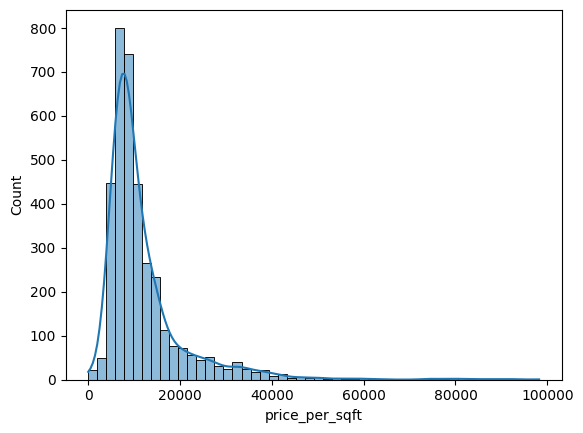

In [65]:
sns.histplot(df['price_per_sqft'], bins=50, kde=True)

<Axes: ylabel='price_per_sqft'>

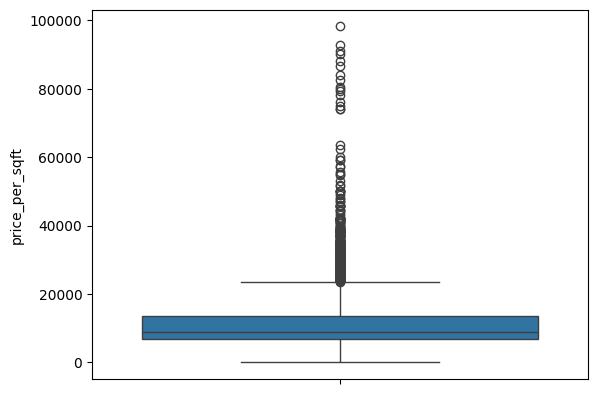

In [66]:
sns.boxplot(df['price_per_sqft'])

In [67]:
skewness = df['price_per_sqft'].skew()
kurtosis = df['price_per_sqft'].kurtosis()
print(f'Skewness: {skewness}')
print(f'Kurtosis: {kurtosis}')

Skewness: 3.439615665879571
Kurtosis: 18.045508045747695


lets apply 'log' transformation

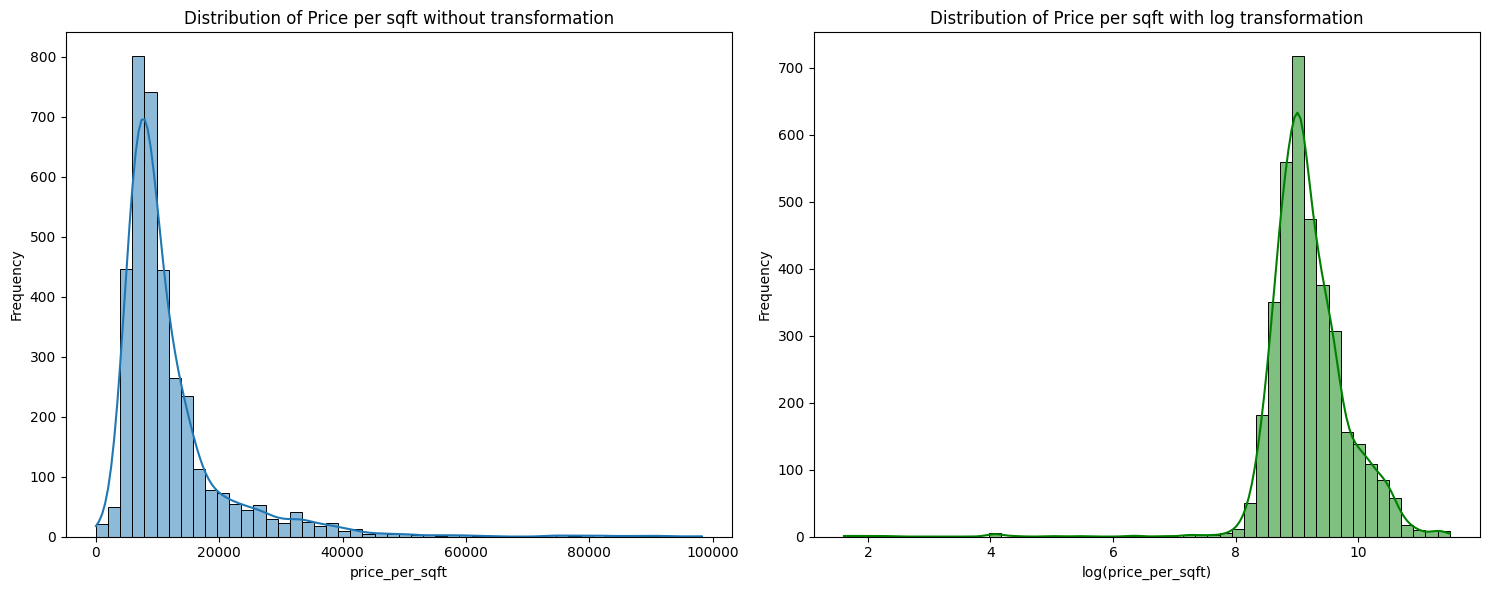

In [68]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
sns.histplot(df['price_per_sqft'], bins=50, kde=True)
plt.title('Distribution of Price per sqft without transformation')
plt.xlabel('price_per_sqft')
plt.ylabel('Frequency')
plt.subplot(1,2,2)
sns.histplot(np.log1p(df['price_per_sqft']), bins=50, kde=True, color='green')
plt.title('Distribution of Price per sqft with log transformation')
plt.xlabel('log(price_per_sqft)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

not much change

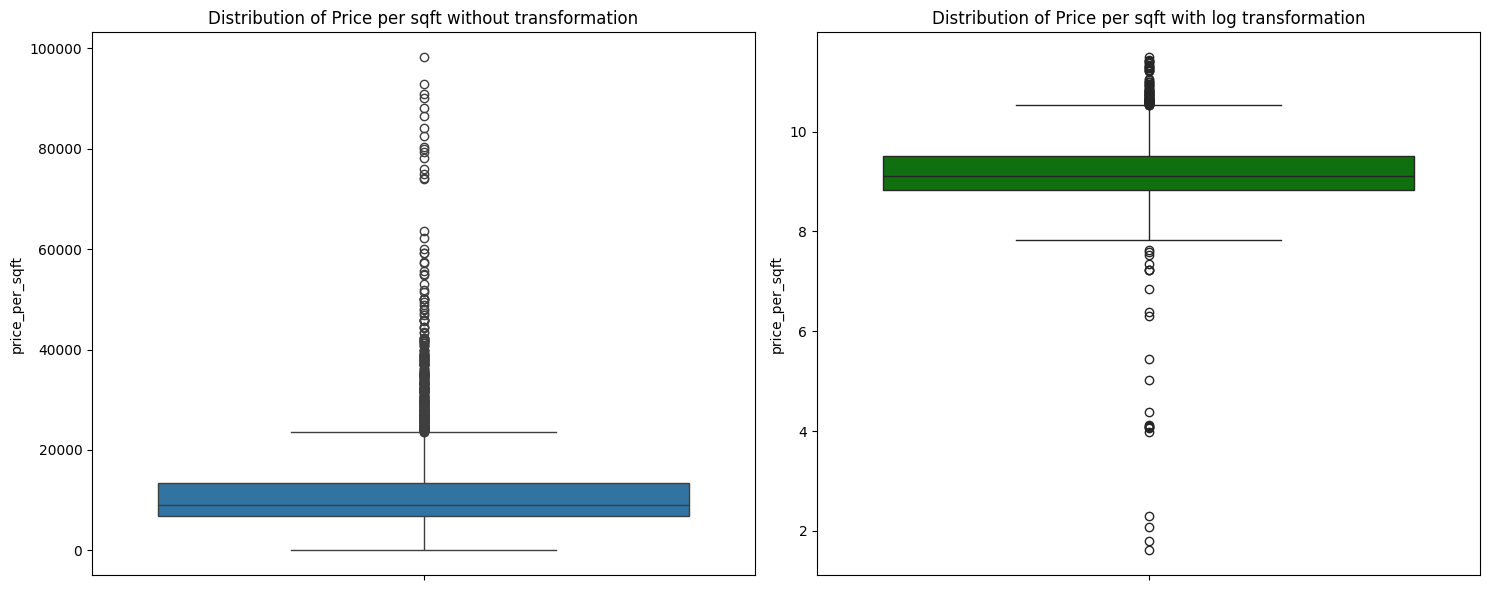

In [69]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
sns.boxplot(df['price_per_sqft'])
plt.title('Distribution of Price per sqft without transformation')
plt.subplot(1,2,2)
sns.boxplot(np.log1p(df['price_per_sqft']), color='green')
plt.title('Distribution of Price per sqft with log transformation')
plt.tight_layout()
plt.show()

In [70]:
np.log1p(df['price_per_sqft']).skew()

np.float64(-1.9936801049985688)

In [71]:
np.log1p(df['price_per_sqft']).kurtosis()

np.float64(23.51337800750399)

**area**

In [72]:
df['area'].isnull().sum()

np.int64(0)

In [73]:
df['area'].describe()

count      3644.000000
mean       2903.986004
std       23217.145797
min          50.000000
25%        1250.000000
50%        1735.065000
75%        2298.137500
max      875000.000000
Name: area, dtype: float64

<Axes: xlabel='area', ylabel='Count'>

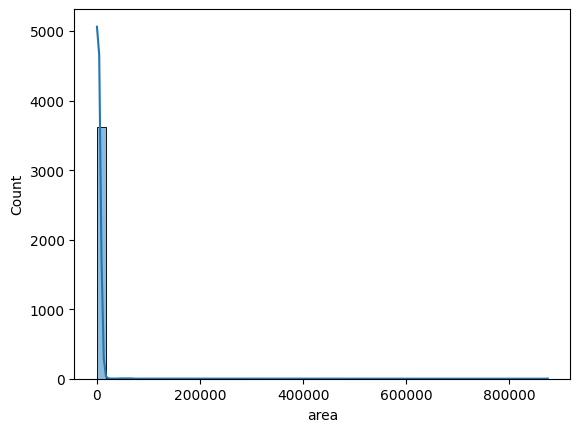

In [74]:
sns.histplot(df['area'], bins=50, kde=True)

<Axes: ylabel='area'>

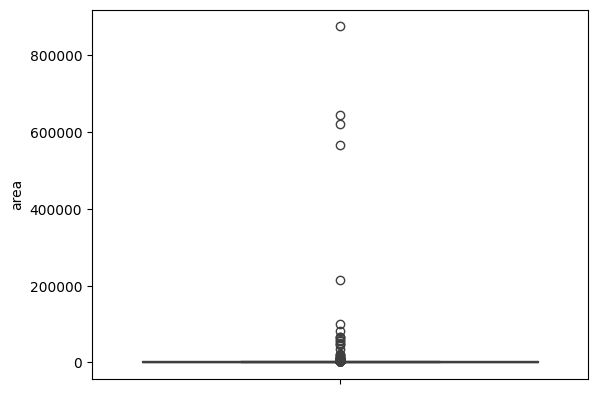

In [75]:
sns.boxplot(df['area'])

In [76]:
df[df['area'] >= 200000]

,property_type,sector,society,price,price_per_sqft,area,super_built_up_area,built_up_area,carpet_area,bedRoom,bathroom,balcony,floorNum,agePossession,store room,servant room,pooja room,study room,others,East,North,North-East,North-West,South,South-East,South-West,Unknown,West,furnish_type,luxury_score
972,flat,sector 95,signature the roselia.,0.45,7.0,642857.14,NaN,NaN,569243.0,2.0,2.0,2,2.0,new property,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,299.0
314,house,sector 50,NaN,5.00,232.0,215517.24,NaN,40.0,NaN,6.0,5.0,3+,2.0,new property,0,1,1,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2,NaN
2812,flat,sector 107,signature global solera,0.51,9.0,566666.67,NaN,NaN,514396.0,2.0,2.0,1,3.0,new property,0,0,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,122.0
2153,flat,sector 95,ramsons kshitij.,0.31,5.0,620000.00,NaN,NaN,607936.0,2.0,2.0,1,1.0,relatively new,0,0,0,1,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1,213.0
3271,flat,sohna,hcbs sports ville.,0.35,4.0,875000.00,NaN,737147.0,NaN,2.0,2.0,2,8.0,relatively new,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,122.0


here row with index 314 looks real, so except this row i will remove all the other outliers

In [77]:
index = [3271, 972, 2153, 2812]

In [78]:
df.drop(index, inplace=True)

<Axes: xlabel='area', ylabel='Count'>

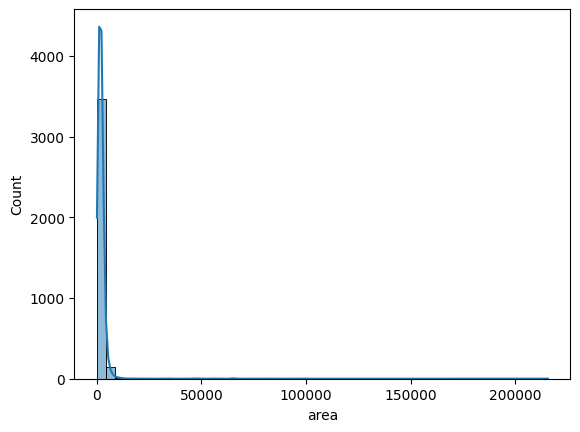

In [79]:
sns.histplot(df['area'], bins=50, kde=True)

In [80]:
df[df['area'] >= 50000]

,property_type,sector,society,price,price_per_sqft,area,super_built_up_area,built_up_area,carpet_area,bedRoom,bathroom,balcony,floorNum,agePossession,store room,servant room,pooja room,study room,others,East,North,North-East,North-West,South,South-East,South-West,Unknown,West,furnish_type,luxury_score
354,house,sector 28,dlf city plot phase,13.000,1992.0,65261.04,NaN,4200.0,7250.0,10.0,10.0,3+,1.0,unknown,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,NaN
626,house,sector 26,NaN,18.400,1859.0,98977.95,NaN,4500.0,11000.0,6.0,8.0,3+,4.0,relatively new,1,1,1,0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2,202.0
2155,flat,sector 95,rof ananda,0.380,58.0,65517.24,NaN,NaN,64412.0,3.0,2.0,1,12.0,relatively new,0,0,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,156.0
314,house,sector 50,NaN,5.000,232.0,215517.24,NaN,40.0,NaN,6.0,5.0,3+,2.0,new property,0,1,1,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2,NaN
941,flat,sector 86,pyramid elite,0.460,79.0,58227.85,NaN,NaN,58141.0,2.0,2.0,1,0.0,unknown,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,40.0
3167,flat,sector 95,rof ananda,0.375,58.0,64655.17,NaN,NaN,64529.0,2.0,2.0,2,10.0,new property,0,0,0,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,40.0
2154,flat,sector 95,rof ananda,0.330,60.0,55000.00,NaN,NaN,54917.0,2.0,2.0,1,13.0,relatively new,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,105.0
286,house,sector 11,ganpati heights apartment,1.250,151.0,82781.46,NaN,294.0,NaN,10.0,6.0,2,3.0,old,0,0,0,0,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,35.0


In [81]:
index = [2154, 941, 3167, 2155]

In [82]:
df.drop(index, inplace=True)

<Axes: xlabel='area', ylabel='Count'>

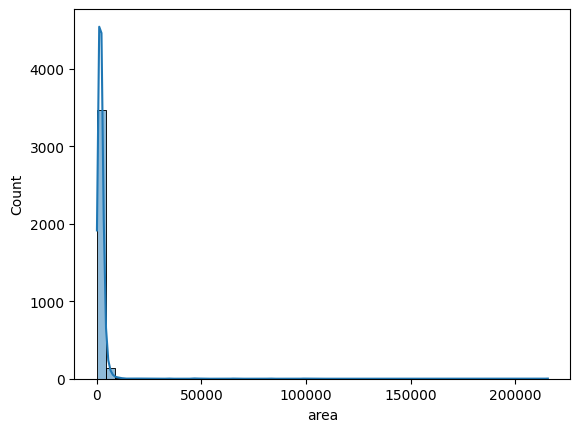

In [83]:
sns.histplot(df['area'], bins=50, kde=True)

**bedRoom**

In [84]:
df['bedRoom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bedRoom'>

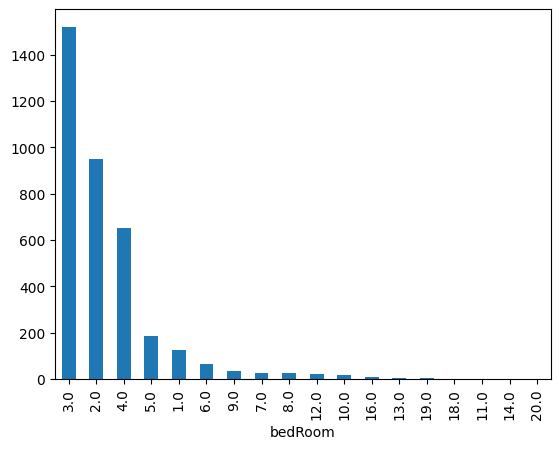

In [85]:
df['bedRoom'].value_counts().plot(kind='bar')

([<matplotlib.patches.Wedge at 0x18fc65a5670>,
 [Text(0.19530846513964664, 1.0825223339242454, '3.0'),
  Text(-0.9581177194054643, -0.5403798994793128, '2.0'),
  Text(0.4367150708822911, -1.009593951479641, '4.0'),
  Text(1.0135492985724512, -0.42745504952368063, '5.0'),
  Text(1.0926915184370147, -0.12659085881615315, '1.0')],
 [Text(0.10653189007617088, 0.5904667275950429, '44.3%'),
  Text(-0.5226096651302532, -0.2947526724432615, '27.7%'),
  Text(0.23820822048124968, -0.5506876098979859, '18.9%'),
  Text(0.5528450719486097, -0.2331572997401894, '5.4%'),
  Text(0.5960135555110989, -0.06904955935426535, '3.7%')])

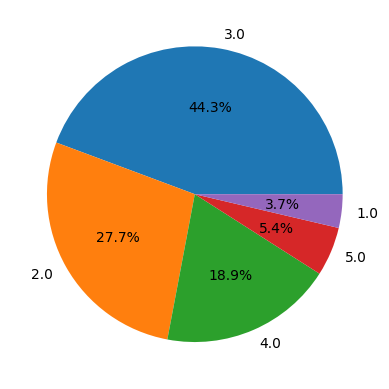

In [86]:
plt.pie(df['bedRoom'].value_counts().head(), labels=df['bedRoom'].value_counts().head().index, autopct='%1.1f%%')

**bathroom**

In [87]:
df['bathroom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bathroom'>

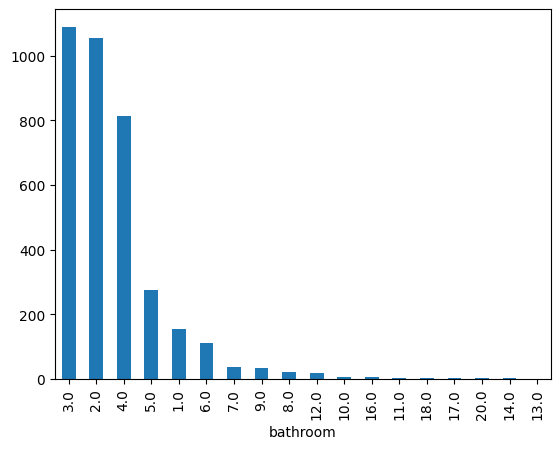

In [88]:
df['bathroom'].value_counts().plot(kind='bar')

([<matplotlib.patches.Wedge at 0x18fc66c54c0>,
 [Text(0.583814910871391, 0.9322875896654583, '3.0'),
  Text(-1.089222143854206, 0.15360703544319673, '2.0'),
  Text(0.024492064771465576, -1.0997273019995595, '4.0'),
  Text(0.9434850634143981, -0.5655403921153019, '5.0'),
  Text(1.0887903675609585, -0.15663823130536517, '1.0')],
 [Text(0.3184444968389405, 0.5085205034538863, '32.2%'),
  Text(-0.5941211693750214, 0.08378565569628911, '31.2%'),
  Text(0.01335930805716304, -0.5998512556361233, '24.0%'),
  Text(0.5146282164078534, -0.30847657751743734, '8.1%'),
  Text(0.59388565503325, -0.0854390352574719, '4.5%')])

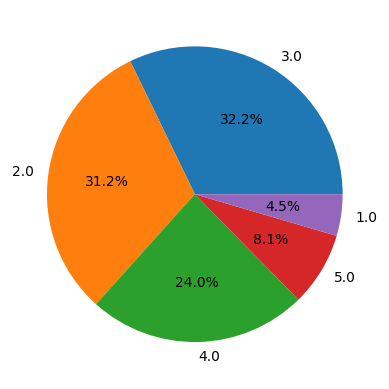

In [89]:
plt.pie(df['bathroom'].value_counts().head(), labels=df['bathroom'].value_counts().head().index, autopct='%1.1f%%')

**balcony**

In [90]:
df['balcony'].isnull().sum()

np.int64(0)

<Axes: xlabel='balcony'>

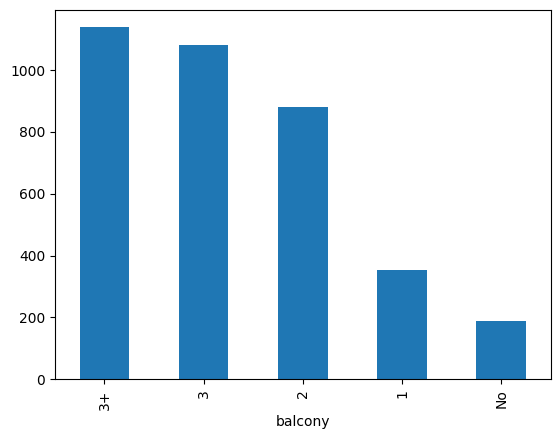

In [91]:
df['balcony'].value_counts().plot(kind='bar')

In [92]:
bal = df[df['balcony'] != 'No'] 

([<matplotlib.patches.Wedge at 0x18fc677d580>,
 [Text(0.5609542294621105, 0.9462189770072095, '3+'),
  Text(-1.0957971776562916, 0.09606531861450206, '3'),
  Text(0.13840312590433335, -1.0912582529996782, '2'),
  Text(1.0436257778957099, -0.34762801341602867, '1')],
 [Text(0.30597503425206024, 0.5161194420039324, '33.0%'),
  Text(-0.5977075514488863, 0.052399264698819295, '31.3%'),
  Text(0.07549261412963637, -0.5952317743634608, '25.5%'),
  Text(0.5692504243067508, -0.18961528004510653, '10.2%')])

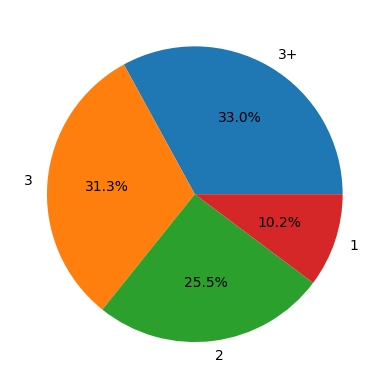

In [93]:
plt.pie(bal['balcony'].value_counts(), labels=bal['balcony'].value_counts().index, autopct='%1.1f%%')

**floorNum**

In [94]:
df['floorNum'].isnull().sum()

np.int64(17)

In [95]:
df['floorNum'].value_counts()

floorNum
 3.0     479
 2.0     478
 1.0     331
 4.0     298
 8.0     197
 6.0     187
 10.0    178
 7.0     176
 5.0     165
 9.0     162
 12.0    159
 0.0     130
 14.0    115
 11.0    114
 15.0     82
 17.0     53
 16.0     52
 13.0     43
 18.0     36
 19.0     33
 20.0     27
 23.0     17
 21.0     15
 22.0     13
 24.0     11
 25.0     10
 27.0     10
-1.0       7
 30.0      5
 26.0      5
 29.0      4
 33.0      4
 28.0      4
 31.0      3
 34.0      3
 35.0      2
 43.0      2
 32.0      2
 39.0      2
 51.0      1
 44.0      1
 40.0      1
 38.0      1
 45.0      1
Name: count, dtype: int64

<Axes: xlabel='floorNum'>

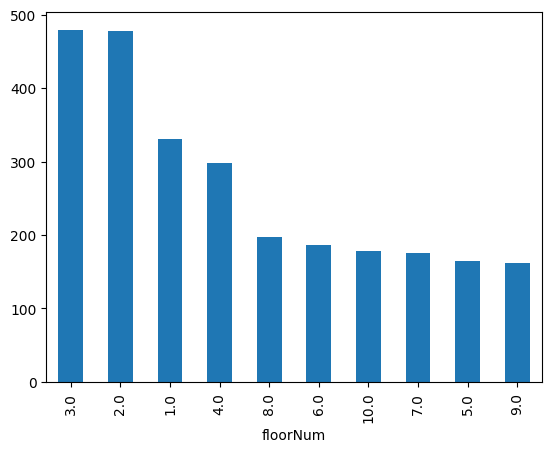

In [96]:
df['floorNum'].value_counts().head(10).plot(kind='bar')

([<matplotlib.patches.Wedge at 0x18fc46ef740>,
 [Text(0.927487293535264, 0.5914112954033183, '3.0'),
  Text(-0.14363265387859492, 1.0905822576677984, '2.0'),
  Text(-0.9751177192662746, 0.5090632903411313, '1.0'),
  Text(-1.06181228482562, -0.28732328794129564, '4.0'),
  Text(-0.7252596624452279, -0.8270419711416309, '8.0'),
  Text(-0.28795171787818674, -1.061642033913033, '6.0'),
  Text(0.1835918949418775, -1.0845708903117632, '10.0'),
  Text(0.6094329740906976, -0.9157463896139407, '7.0'),
  Text(0.920413932858987, -0.602360516799576, '5.0'),
  Text(1.0797912676204224, -0.20988286821625435, '9.0')],
 [Text(0.505902160110144, 0.32258797931090083, '18.1%'),
  Text(-0.07834508393377904, 0.5948630496369808, '18.0%'),
  Text(-0.5318823923270588, 0.27767088564061704, '12.5%'),
  Text(-0.5791703371776108, -0.15672179342252487, '11.2%'),
  Text(-0.39559617951557885, -0.45111380244088956, '7.4%'),
  Text(-0.15706457338810184, -0.5790774730434725, '7.1%'),
  Text(0.10014103360466044, -0.591584

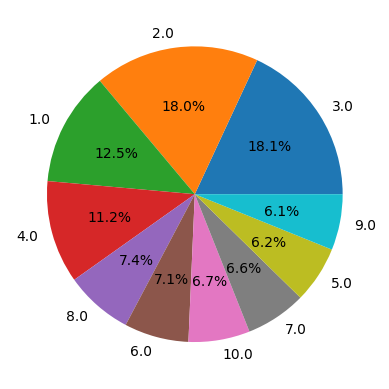

In [97]:
plt.pie(df['floorNum'].value_counts().head(10), labels=df['floorNum'].value_counts().head(10).index, autopct='%1.1f%%')

<Axes: ylabel='floorNum'>

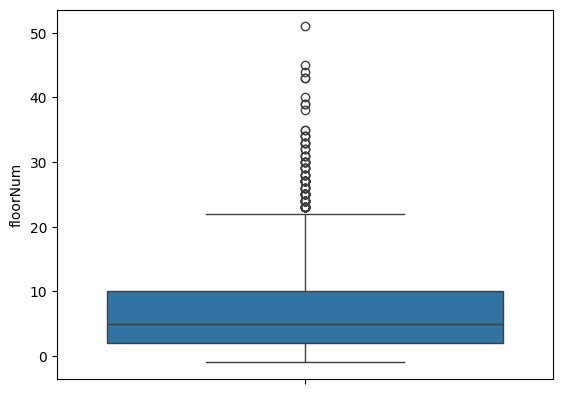

In [98]:
sns.boxplot(df['floorNum'])

1) the majority of the properties lies between the 0 t0 25th floor
2) there are some outliers
3) there are 17 null values
4) floor 1,2,3 and 4 are preffered the most by the buyers with the 3rd being the most favourite.
5) the boxplot shows that the most of the properties lies near the lower floors and the IQR lies between the 0 and 10

**ageposession**

In [99]:
df['agePossession'].isnull().sum()

np.int64(1)

In [100]:
df['agePossession'].value_counts()

agePossession
relatively new        1604
new property           567
moderately old         546
unknown                441
old                    284
under construction     193
Name: count, dtype: int64

<Axes: xlabel='agePossession'>

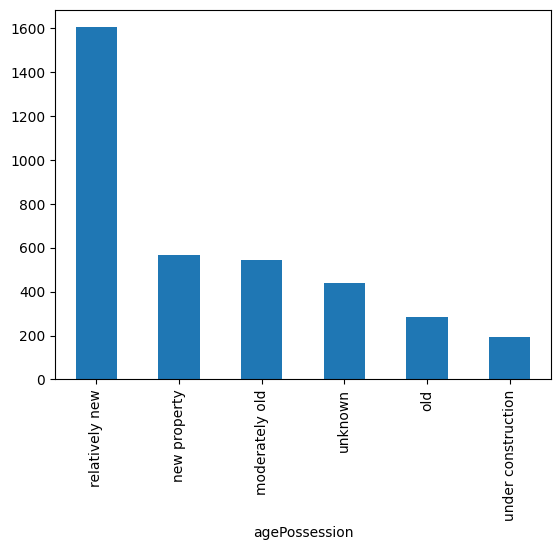

In [101]:
df['agePossession'].value_counts().plot(kind='bar')

([<matplotlib.patches.Wedge at 0x18fc6ef2bd0>,
 [Text(0.2018221326668308, 1.081326882476253, 'relatively new'),
  Text(-1.0919577263787204, -0.13277169804523822, 'new property'),
  Text(-0.5156257568778325, -0.9716635625792307, 'moderately old'),
  Text(0.3927993161895865, -1.0274768596912505, 'unknown'),
  Text(0.9206778068955684, -0.6019571213051365, 'old'),
  Text(1.0847328061081198, -0.18263279922512302, 'under construction')],
 [Text(0.11008479963645317, 0.5898146631688652, '44.1%'),
  Text(-0.5956133052974838, -0.07242092620649357, '15.6%'),
  Text(-0.28125041284245406, -0.5299983068613985, '15.0%'),
  Text(0.21425417246704717, -0.5604419234679547, '12.1%'),
  Text(0.50218789467031, -0.32834024798461986, '7.8%'),
  Text(0.591672439695338, -0.09961789048643073, '5.3%')])

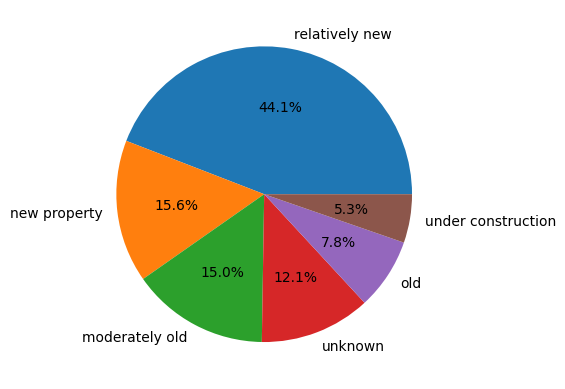

In [102]:
plt.pie(df['agePossession'].value_counts(), labels=df['agePossession'].value_counts().index, autopct='%1.1f%%')

**roomtype**

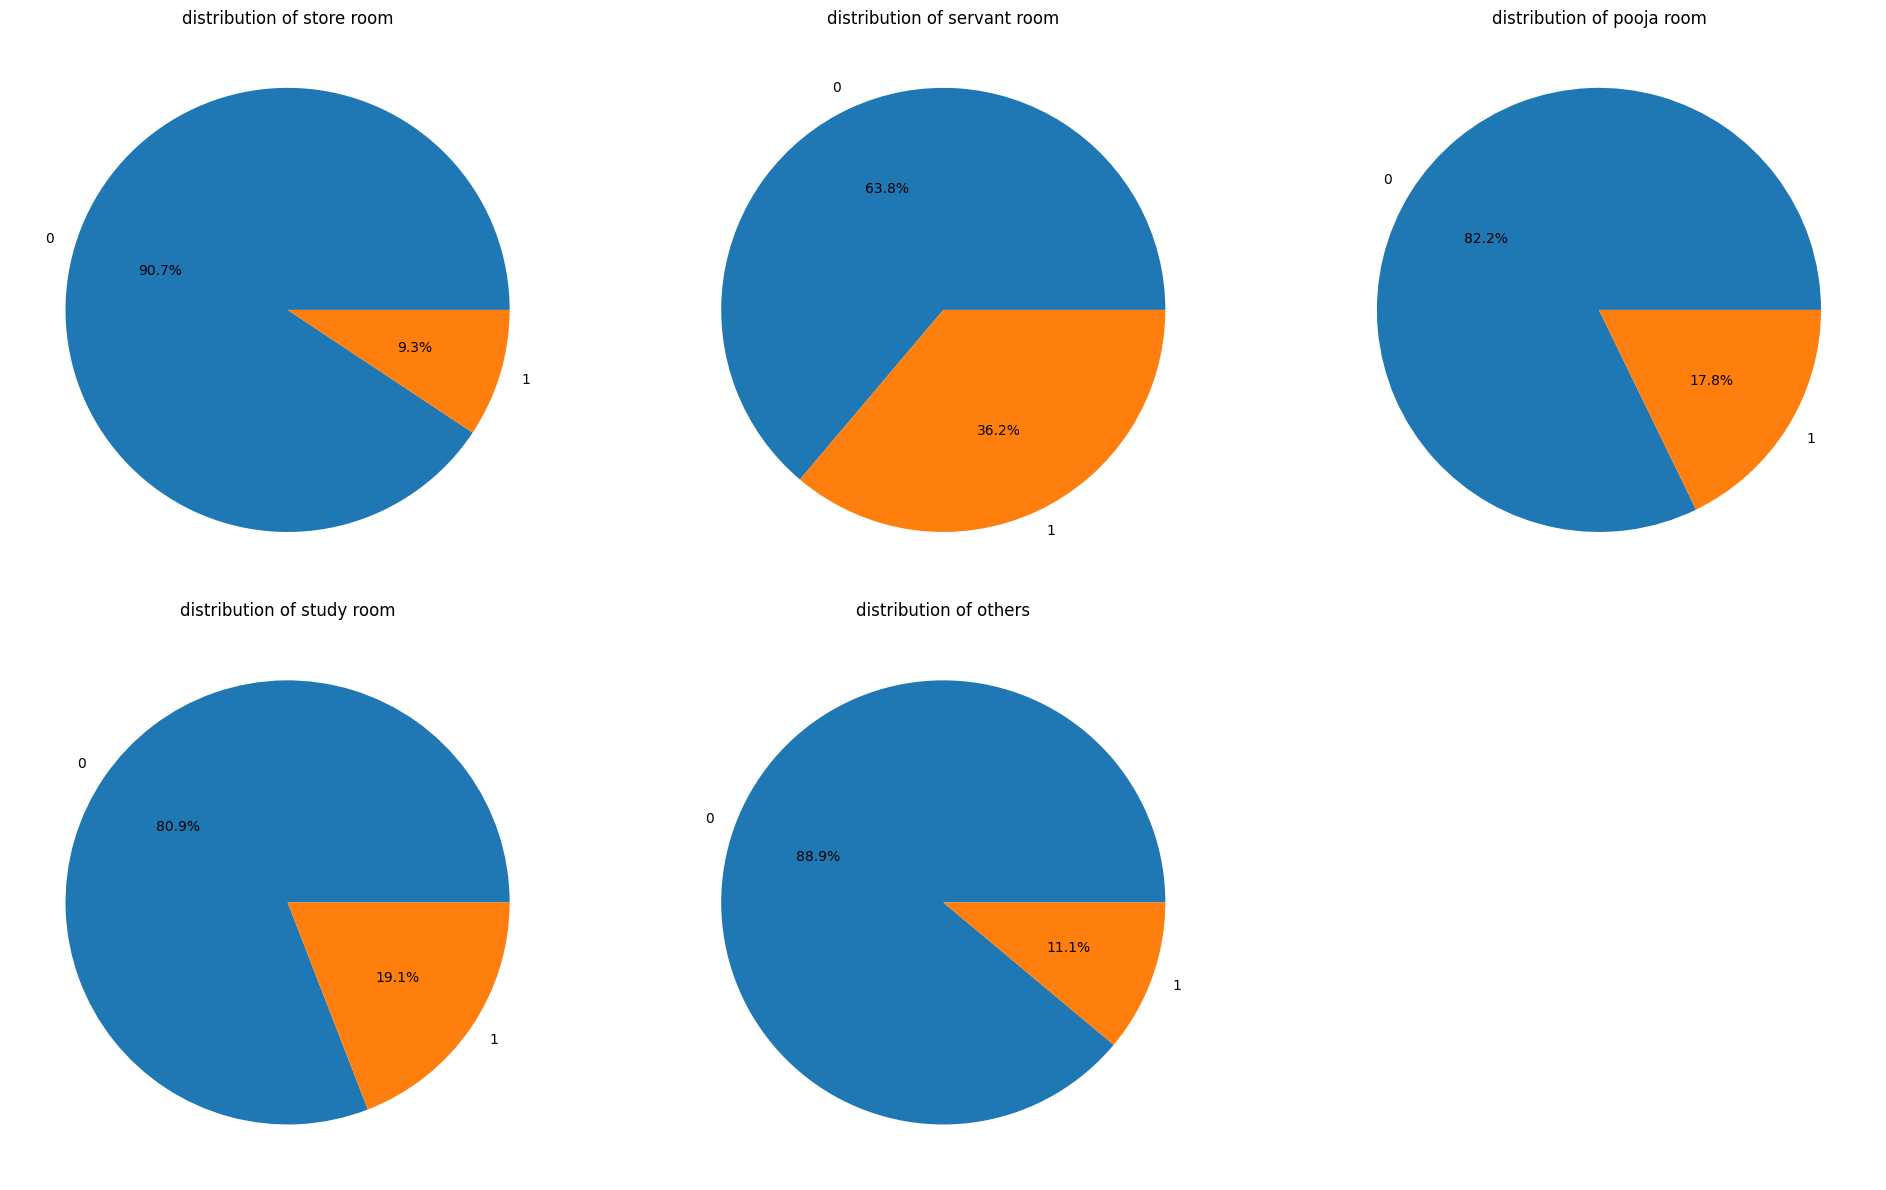

In [106]:
plt.figure(figsize=(20,12))
for i, column in enumerate(['store room', 'servant room', 'pooja room', 'study room', 'others'],1):
    ax = plt.subplot(2,3,i)
    plt.pie(df[column].value_counts(), labels=df[column].value_counts().index, autopct='%1.1f%%')
    plt.title(f'distribution of {column}')
plt.tight_layout()
plt.show()

**direction**

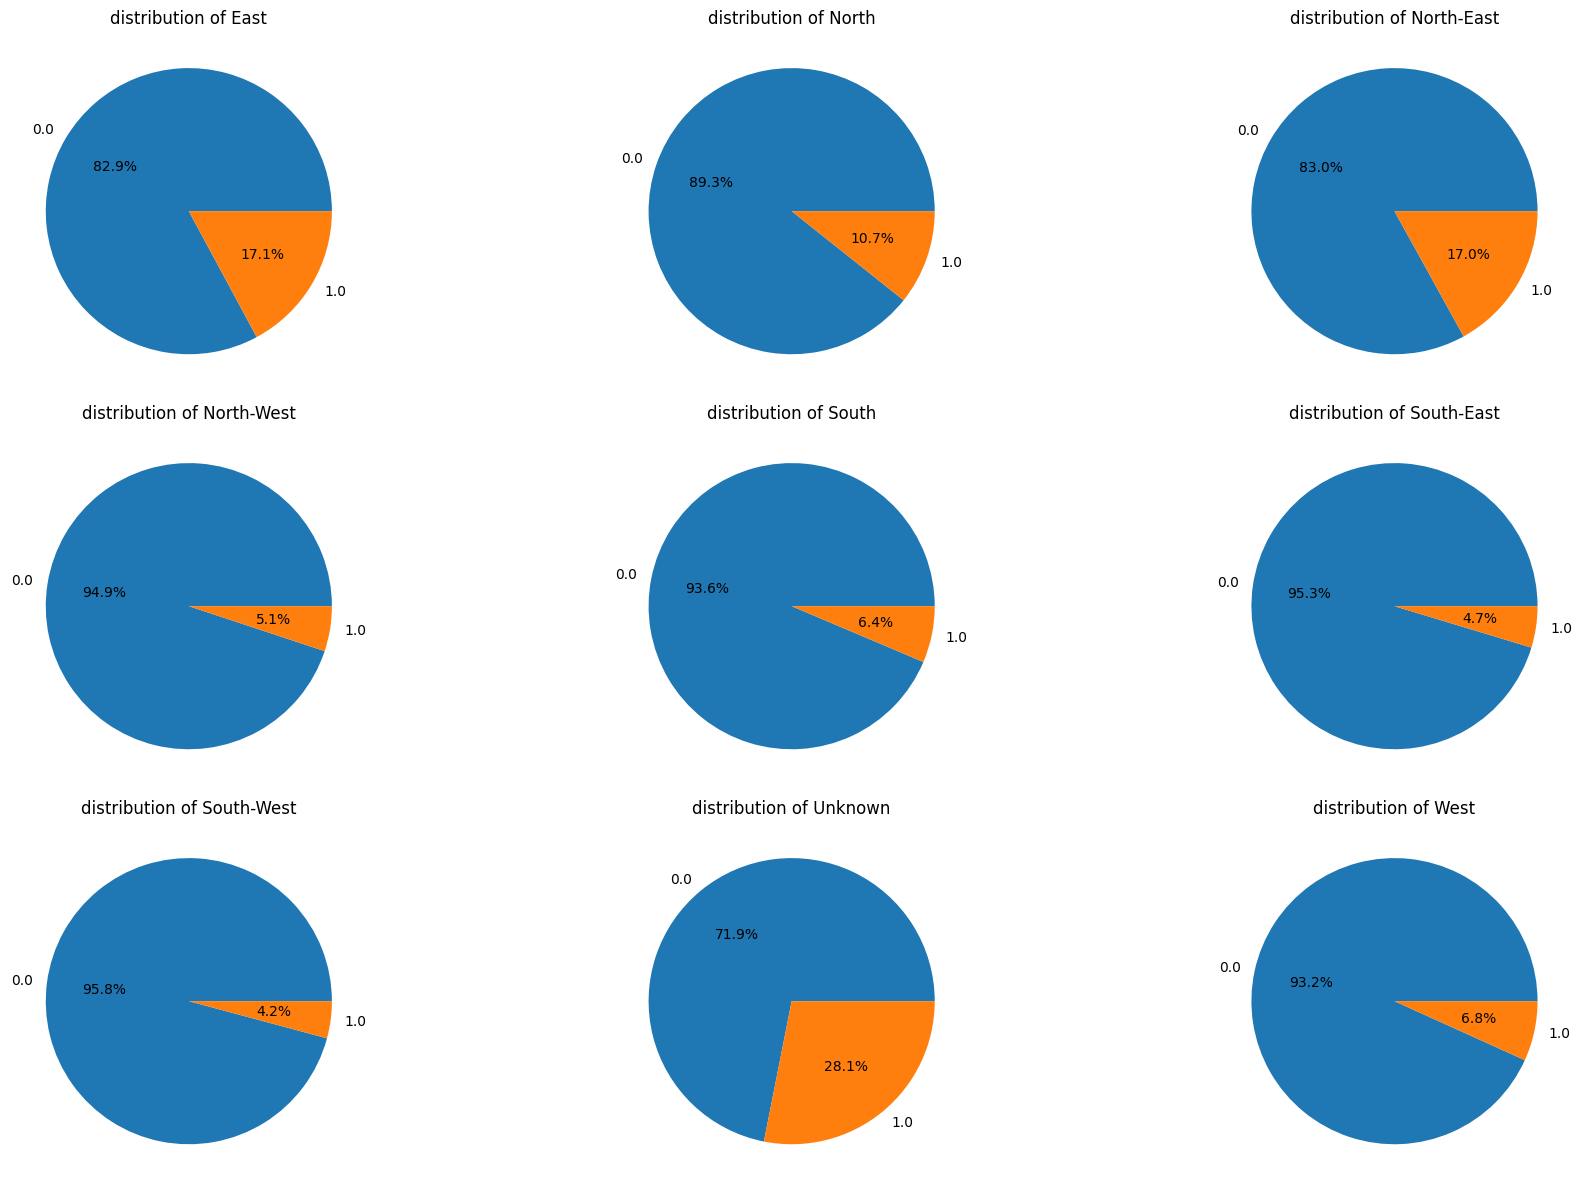

In [107]:
plt.figure(figsize=(20,12))

for i, column in enumerate(['East', 'North', 'North-East', 'North-West', 'South', 'South-East', 'South-West', 'Unknown', 'West'],1):
    ax = plt.subplot(3,3,i)
    plt.pie(df[column].value_counts(), labels=df[column].value_counts().index, autopct='%1.1f%%')
    plt.title(f'distribution of {column}')

plt.tight_layout()
plt.show()

**furnish_type**

In [108]:
df['furnish_type'].isnull().sum()

np.int64(0)

<Axes: xlabel='furnish_type'>

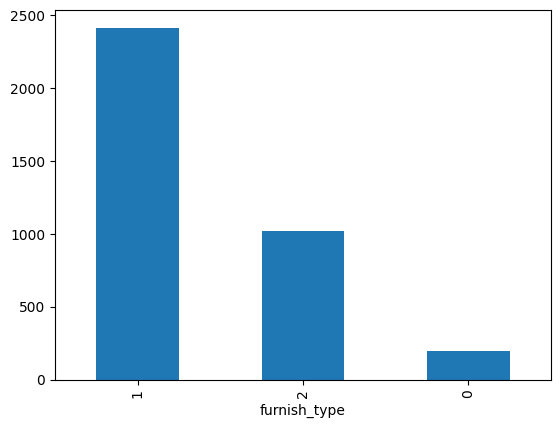

In [111]:
df['furnish_type'].value_counts().plot(kind='bar')

([<matplotlib.patches.Wedge at 0x18fc8771c10>,
 [Text(-0.5434021841882282, 0.9564068518258655, '1'),
  Text(0.3744358026494214, -1.0343103159566203, '2'),
  Text(1.0842642502726703, -0.18539427062518496, '0')],
 [Text(-0.2964011913753971, 0.5216764646322902, '66.4%'),
  Text(0.204237710536048, -0.5641692632490656, '28.2%'),
  Text(0.5914168637850928, -0.10112414761373724, '5.4%')])

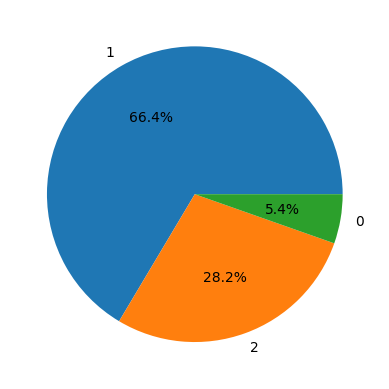

In [112]:
plt.pie(df['furnish_type'].value_counts(), labels=df['furnish_type'].value_counts().index, autopct='%1.1f%%')

**luxuryscore**

In [113]:
df['luxury_score'].isnull().sum()

np.int64(492)

In [114]:
df['luxury_score'].describe()

count    3144.000000
mean      305.520992
std       202.667002
min         8.000000
25%       147.000000
50%       243.500000
75%       466.000000
max       708.000000
Name: luxury_score, dtype: float64

<Axes: xlabel='luxury_score', ylabel='Count'>

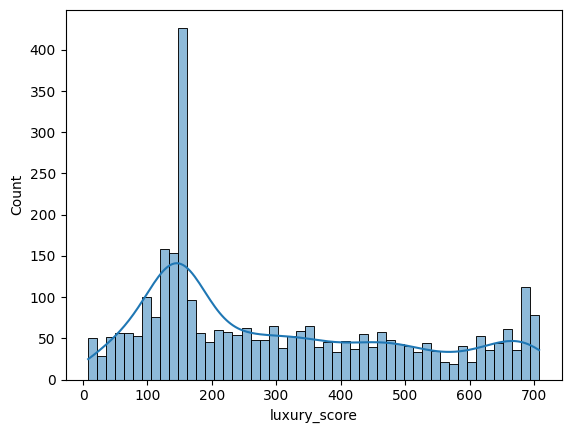

In [115]:
sns.histplot(df['luxury_score'], bins=50, kde=True)

there are mulitple peaks in the distribution(which means it's a mulit-modal distribution). first peak is at around 150(lower luxury score) and the 2nd peak is at 700(high luxuyr score)

<Axes: ylabel='luxury_score'>

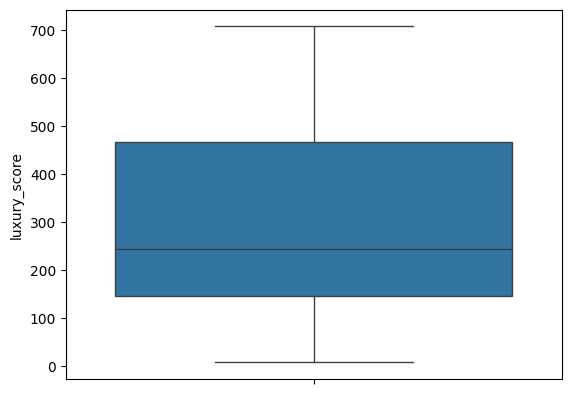

In [117]:
sns.boxplot(df['luxury_score'])

from the boxplot we can clearly see that the most of the properties have luxury score in between 150-480

In [118]:
df.head()

,property_type,sector,society,price,price_per_sqft,area,super_built_up_area,built_up_area,carpet_area,bedRoom,bathroom,balcony,floorNum,agePossession,store room,servant room,pooja room,study room,others,East,North,North-East,North-West,South,South-East,South-West,Unknown,West,furnish_type,luxury_score
2617,flat,sector 81,bestech park view ananda.,1.15,6927.0,1660.17,1660.0,1660.0,1082.0,3.0,2.0,3+,12.0,relatively new,0,0,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,424.0
1818,flat,sector 106,paras dews,1.13,6406.0,1763.97,1760.0,1760.0,1130.0,3.0,4.0,3+,18.0,relatively new,0,1,0,1,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1,154.0
3779,flat,sector 92,sare homes,0.82,5384.0,1523.03,1523.0,1523.0,NaN,3.0,3.0,3+,12.0,relatively new,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,434.0
1658,flat,sector 102,conscient heritage max.,1.82,9011.0,2019.75,1942.0,1942.0,NaN,3.0,4.0,3+,12.0,relatively new,0,1,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1,420.0
2330,flat,sector 69,tulip white.,0.90,6787.0,1326.06,NaN,NaN,1326.0,3.0,2.0,3,6.0,relatively new,0,0,1,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1,469.0
